# 02b - Baseline Models (PVGIS)

Entrena y evalúa los modelos base de deep learning sobre el dataset PVGIS-ERA5.

**Modelos:** MLP · LSTM · GRU  
**Seeds:** 0–4 (5 ejecuciones independientes por modelo)  
**Input:** ventana de 24 h → predicción 1 h adelante  
**Features:** TempAir, WindSpeed, hour, dayofyear, month (n=5)

Salidas:
- `outputs/pvgis/models/` — modelos `.keras`
- `outputs/pvgis/results/baseline_results.csv`
- `outputs/pvgis/results/baseline_summary.csv`
- `outputs/pvgis/figures/`

In [1]:
import os
import json
import time
import random
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, LSTM, GRU, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

I0000 00:00:1780364270.978766   79144 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780364270.979935   79144 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1780364271.080865   79144 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780364273.642436   79144 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

TensorFlow: 2.21.0
GPUs: []


E0000 00:00:1780364276.862785   79144 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1780364276.863430   79198 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1780364276.887074   79144 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [2]:
BASE_DIR    = "/home/sergioperez/servidorjs"
PVGIS_DIR   = os.path.join(BASE_DIR, "outputs", "pvgis")
ARRAYS_DIR  = os.path.join(PVGIS_DIR, "arrays")
SCALERS_DIR = os.path.join(PVGIS_DIR, "scalers")
MODELS_DIR  = os.path.join(PVGIS_DIR, "models")
RESULTS_DIR = os.path.join(PVGIS_DIR, "results")
FIGURES_DIR = os.path.join(PVGIS_DIR, "figures")

for d in [MODELS_DIR, RESULTS_DIR, FIGURES_DIR]:
    os.makedirs(d, exist_ok=True)

print("Directorios listos.")

Directorios listos.


In [3]:
def set_seed(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

## 1. Cargar datos y configuración

In [4]:
with open(os.path.join(PVGIS_DIR, "preprocessing_config.json")) as f:
    CONFIG = json.load(f)

print(json.dumps(CONFIG, indent=2))

{
  "file_name": "pvgis_raw.csv",
  "source": "PVGIS-ERA5",
  "latitude": 20.563425,
  "longitude": -100.36943889,
  "timezone_offset_h": -6,
  "target": "GHI",
  "window_size": 24,
  "horizon": 1,
  "train_ratio": 0.7,
  "val_ratio": 0.15,
  "test_ratio": 0.15,
  "irradiance_threshold": 50,
  "features": [
    "TempAir",
    "WindSpeed",
    "hour",
    "dayofyear",
    "month"
  ],
  "n_features": 5,
  "n_samples": 34992,
  "train_size": 24520,
  "val_size": 5235,
  "test_size": 5237
}


In [5]:
X_train = np.load(os.path.join(ARRAYS_DIR, "X_train.npy"))
y_train = np.load(os.path.join(ARRAYS_DIR, "y_train.npy"))
X_val   = np.load(os.path.join(ARRAYS_DIR, "X_val.npy"))
y_val   = np.load(os.path.join(ARRAYS_DIR, "y_val.npy"))
X_test  = np.load(os.path.join(ARRAYS_DIR, "X_test.npy"))
y_test  = np.load(os.path.join(ARRAYS_DIR, "y_test.npy"))

daylight_test  = np.load(os.path.join(ARRAYS_DIR, "daylight_test.npy"))
timestamps_test = np.load(os.path.join(ARRAYS_DIR, "timestamps_test.npy"), allow_pickle=True)

scaler_y = joblib.load(os.path.join(SCALERS_DIR, "scaler_y.pkl"))

WINDOW_SIZE = X_train.shape[1]   # 24
N_FEATURES  = X_train.shape[2]   # 5

print(f"Train : {X_train.shape}  {y_train.shape}")
print(f"Val   : {X_val.shape}    {y_val.shape}")
print(f"Test  : {X_test.shape}   {y_test.shape}")
print(f"Window: {WINDOW_SIZE} h  |  Features: {N_FEATURES}")

Train : (24520, 24, 5)  (24520, 1)
Val   : (5235, 24, 5)    (5235, 1)
Test  : (5237, 24, 5)   (5237, 1)
Window: 24 h  |  Features: 5


## 2. Configuración del entrenamiento

In [6]:
EPOCHS        = 100
BATCH_SIZE    = 32
LEARNING_RATE = 0.001
PATIENCE      = 10
SEEDS         = [0, 1, 2, 3, 4]

## 3. Definición de modelos

In [7]:
def build_mlp(input_shape, learning_rate=0.001):
    model = Sequential([
        Flatten(input_shape=input_shape),
        Dense(128, activation="relu"),
        Dropout(0.2),
        Dense(64, activation="relu"),
        Dropout(0.2),
        Dense(32, activation="relu"),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate), loss="mse", metrics=["mae"])
    return model


def build_lstm(input_shape, learning_rate=0.001):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(32, activation="relu"),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate), loss="mse", metrics=["mae"])
    return model


def build_gru(input_shape, learning_rate=0.001):
    model = Sequential([
        GRU(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        GRU(32),
        Dropout(0.2),
        Dense(32, activation="relu"),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate), loss="mse", metrics=["mae"])
    return model


MODELS = {
    "MLP":  build_mlp,
    "LSTM": build_lstm,
    "GRU":  build_gru,
}

## 4. Funciones de evaluación

In [8]:
def compute_metrics(y_true, y_pred):
    return {
        "MAE":  mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2":   r2_score(y_true, y_pred),
    }


def compute_daylight_metrics(y_true, y_pred, mask):
    return compute_metrics(y_true[mask], y_pred[mask])

## 5. Loop de entrenamiento

In [9]:
def train_and_evaluate(model_name, build_fn, seed):
    set_seed(seed)
    print(f"\n{'='*50}")
    print(f"  {model_name}  |  Seed {seed}")
    print(f"{'='*50}")

    model = build_fn(
        input_shape=(WINDOW_SIZE, N_FEATURES),
        learning_rate=LEARNING_RATE
    )

    cb = EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True)

    t0 = time.time()
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[cb],
        verbose=1
    )
    elapsed = time.time() - t0

    y_pred_scaled = model.predict(X_test, verbose=0)
    y_pred = scaler_y.inverse_transform(y_pred_scaled)
    y_true = scaler_y.inverse_transform(y_test)

    overall  = compute_metrics(y_true, y_pred)
    daylight = compute_daylight_metrics(y_true, y_pred, daylight_test)

    result = {
        "Model":                  model_name,
        "Seed":                   seed,
        "Test_MAE":               overall["MAE"],
        "Test_RMSE":              overall["RMSE"],
        "Test_R2":                overall["R2"],
        "Daylight_MAE":           daylight["MAE"],
        "Daylight_RMSE":          daylight["RMSE"],
        "Daylight_R2":            daylight["R2"],
        "Training_Time_Seconds":  elapsed,
        "Epochs":                 len(history.history["loss"]),
    }

    print(f"  Test MAE={overall['MAE']:.2f}  RMSE={overall['RMSE']:.2f}  R2={overall['R2']:.4f}")
    print(f"  Daylight MAE={daylight['MAE']:.2f}  R2={daylight['R2']:.4f}")
    print(f"  Time: {elapsed:.1f}s  |  Epochs: {result['Epochs']}")

    return result, history, model, y_pred, y_true

In [10]:
all_results  = []
histories    = {}
trained_models = {}
predictions  = {}

for model_name, build_fn in MODELS.items():
    for seed in SEEDS:
        result, history, model, y_pred, y_true = train_and_evaluate(
            model_name, build_fn, seed
        )
        key = f"{model_name}_{seed}"
        all_results.append(result)
        histories[key]      = history
        trained_models[key] = model
        predictions[key]    = {"y_true": y_true, "y_pred": y_pred}

print("\n✓ Entrenamiento completo.")


  MLP  |  Seed 0


/home/sergioperez/servidorjs/env/lib/python3.13/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0101 - mae: 0.0609 - val_loss: 0.0061 - val_mae: 0.0466
Epoch 2/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0056 - mae: 0.0445 - val_loss: 0.0039 - val_mae: 0.0396
Epoch 3/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0049 - mae: 0.0409 - val_loss: 0.0044 - val_mae: 0.0386
Epoch 4/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0046 - mae: 0.0394 - val_loss: 0.0044 - val_mae: 0.0379
Epoch 5/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0044 - mae: 0.0379 - val_loss: 0.0042 - val_mae: 0.0379
Epoch 6/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0043 - mae: 0.0371 - val_loss: 0.0041 - val_mae: 0.0378
Epoch 7/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0042 - mae: 0.0366 - val_loss: 0.0047 - val_mae: 0.0392
Epoch 8/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0041 - mae: 0.0361 - val_loss: 0.0041 - val_mae: 0.0357
Epoch 9/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/

/home/sergioperez/servidorjs/env/lib/python3.13/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


767/767 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0104 - mae: 0.0642 - val_loss: 0.0131 - val_mae: 0.0712
Epoch 2/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0055 - mae: 0.0453 - val_loss: 0.0081 - val_mae: 0.0545
Epoch 3/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0050 - mae: 0.0421 - val_loss: 0.0094 - val_mae: 0.0569
Epoch 4/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0047 - mae: 0.0401 - val_loss: 0.0071 - val_mae: 0.0484
Epoch 5/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0045 - mae: 0.0385 - val_loss: 0.0050 - val_mae: 0.0400
Epoch 6/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0043 - mae: 0.0378 - val_loss: 0.0063 - val_mae: 0.0452
Epoch 7/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0042 - mae: 0.0370 - val_loss: 0.0039 - val_mae: 0.0347
Epoch 8/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0041 - mae: 0.0365 - val_loss: 0.0038 - val_mae: 0.0353
Epoch 9/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss:

...

767/767 ━━━━━━━━━━━━━━━━━━━━ 27s 28ms/step - loss: 0.0134 - mae: 0.0702 - val_loss: 0.0039 - val_mae: 0.0353
Epoch 2/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - loss: 0.0057 - mae: 0.0457 - val_loss: 0.0031 - val_mae: 0.0298
Epoch 3/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 4544s 6s/step - loss: 0.0050 - mae: 0.0422 - val_loss: 0.0027 - val_mae: 0.0290
Epoch 4/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - loss: 0.0045 - mae: 0.0394 - val_loss: 0.0024 - val_mae: 0.0261
Epoch 5/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - loss: 0.0042 - mae: 0.0376 - val_loss: 0.0025 - val_mae: 0.0273
Epoch 6/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - loss: 0.0040 - mae: 0.0364 - val_loss: 0.0025 - val_mae: 0.0282
Epoch 7/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - loss: 0.0038 - mae: 0.0353 - val_loss: 0.0022 - val_mae: 0.0253
Epoch 8/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - loss: 0.0037 - mae: 0.0347 - val_loss: 0.0022 - val_mae: 0.0267
Epoch 9/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 20s

/home/sergioperez/servidorjs/env/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


767/767 ━━━━━━━━━━━━━━━━━━━━ 27s 28ms/step - loss: 0.0177 - mae: 0.0832 - val_loss: 0.0039 - val_mae: 0.0380
Epoch 2/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - loss: 0.0055 - mae: 0.0466 - val_loss: 0.0029 - val_mae: 0.0301
Epoch 3/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - loss: 0.0048 - mae: 0.0419 - val_loss: 0.0031 - val_mae: 0.0301
Epoch 4/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - loss: 0.0045 - mae: 0.0403 - val_loss: 0.0025 - val_mae: 0.0275
Epoch 5/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - loss: 0.0043 - mae: 0.0389 - val_loss: 0.0025 - val_mae: 0.0302
Epoch 6/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - loss: 0.0040 - mae: 0.0374 - val_loss: 0.0024 - val_mae: 0.0293
Epoch 7/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - loss: 0.0039 - mae: 0.0367 - val_loss: 0.0023 - val_mae: 0.0286
Epoch 8/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - loss: 0.0038 - mae: 0.0361 - val_loss: 0.0023 - val_mae: 0.0275
Epoch 9/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 21s

/home/sergioperez/servidorjs/env/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


767/767 ━━━━━━━━━━━━━━━━━━━━ 27s 28ms/step - loss: 0.0141 - mae: 0.0734 - val_loss: 0.0048 - val_mae: 0.0397
Epoch 2/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - loss: 0.0057 - mae: 0.0463 - val_loss: 0.0035 - val_mae: 0.0337
Epoch 3/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - loss: 0.0049 - mae: 0.0416 - val_loss: 0.0035 - val_mae: 0.0340
Epoch 4/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - loss: 0.0045 - mae: 0.0396 - val_loss: 0.0029 - val_mae: 0.0291
Epoch 5/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - loss: 0.0043 - mae: 0.0385 - val_loss: 0.0028 - val_mae: 0.0285
Epoch 6/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - loss: 0.0041 - mae: 0.0374 - val_loss: 0.0022 - val_mae: 0.0264
Epoch 7/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - loss: 0.0039 - mae: 0.0364 - val_loss: 0.0028 - val_mae: 0.0309
Epoch 8/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - loss: 0.0039 - mae: 0.0360 - val_loss: 0.0023 - val_mae: 0.0258
Epoch 9/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 21s

## 6. Resultados

In [11]:
results_df = pd.DataFrame(all_results)
results_df

,Model,Seed,Test_MAE,Test_RMSE,Test_R2,Daylight_MAE,Daylight_RMSE,Daylight_R2,Training_Time_Seconds,Epochs
0,MLP,0,34.268289,63.477951,0.960713,70.336870,92.537800,0.889683,140.495606,49
1,MLP,1,39.311917,69.907090,0.952352,78.604799,101.796275,0.866504,62.814624,22
2,MLP,2,32.653273,58.021471,0.967177,65.219738,84.558419,0.907888,94.728908,33
3,MLP,3,34.302553,59.800693,0.965133,66.034987,86.986741,0.902521,78.156125,27
4,MLP,4,34.800615,62.299531,0.962158,70.263687,90.797772,0.893793,103.008408,36
5,LSTM,0,33.448134,60.306526,0.964540,67.429445,88.013339,0.900207,439.289366,24
6,LSTM,1,27.652910,51.138910,0.974502,55.165492,74.464768,0.928566,777.004995,43
7,LSTM,2,33.505782,61.203433,0.963478,69.073010,89.289863,0.897291,444.378910,25
8,LSTM,3,29.719341,57.492740,0.967772,60.863159,83.931987,0.909247,584.608286,32
9,LSTM,4,30.307385,54.723696,0.970802,61.218492,79.858104,0.917843,638.375461,35


In [12]:
summary_df = results_df.groupby("Model").agg(
    Test_MAE_mean=("Test_MAE", "mean"),
    Test_MAE_std=("Test_MAE", "std"),
    Test_RMSE_mean=("Test_RMSE", "mean"),
    Test_RMSE_std=("Test_RMSE", "std"),
    Test_R2_mean=("Test_R2", "mean"),
    Test_R2_std=("Test_R2", "std"),
    Daylight_MAE_mean=("Daylight_MAE", "mean"),
    Daylight_MAE_std=("Daylight_MAE", "std"),
    Daylight_R2_mean=("Daylight_R2", "mean"),
    Daylight_R2_std=("Daylight_R2", "std"),
    Time_mean=("Training_Time_Seconds", "mean"),
).round(4)

summary_df

,Test_MAE_mean,Test_MAE_std,Test_RMSE_mean,Test_RMSE_std,Test_R2_mean,Test_R2_std,Daylight_MAE_mean,Daylight_MAE_std,Daylight_R2_mean,Daylight_R2_std,Time_mean
Model,,,,,,,,,,,
GRU,29.5344,3.2309,53.3704,3.8250,0.9721,0.0041,57.5647,4.9502,0.9220,0.0114,1874.9133
LSTM,30.9267,2.5283,56.9731,4.1345,0.9682,0.0045,62.7499,5.5971,0.9106,0.0129,576.7314
MLP,35.0673,2.5069,62.7013,4.5553,0.9615,0.0057,70.0920,5.3093,0.8921,0.0160,95.8407


## 7. Guardar resultados y modelos

In [13]:
results_df.to_csv(os.path.join(RESULTS_DIR, "baseline_results.csv"), index=False)
summary_df.to_csv(os.path.join(RESULTS_DIR, "baseline_summary.csv"))
print("Resultados guardados en:", RESULTS_DIR)

for key, model in trained_models.items():
    model.save(os.path.join(MODELS_DIR, f"{key}.keras"))
print(f"Modelos guardados: {len(trained_models)} archivos en {MODELS_DIR}")

best = results_df.loc[results_df["Daylight_MAE"].idxmin()]
with open(os.path.join(RESULTS_DIR, "best_baseline.json"), "w") as f:
    json.dump(best.to_dict(), f, indent=4, default=str)
print(f"\nMejor modelo baseline: {best['Model']} seed={best['Seed']} "
      f"Daylight_MAE={best['Daylight_MAE']:.2f}")

Resultados guardados en: /home/sergioperez/servidorjs/outputs/pvgis/results
Modelos guardados: 15 archivos en /home/sergioperez/servidorjs/outputs/pvgis/models

Mejor modelo baseline: GRU seed=4 Daylight_MAE=53.56


## 8. Visualizaciones

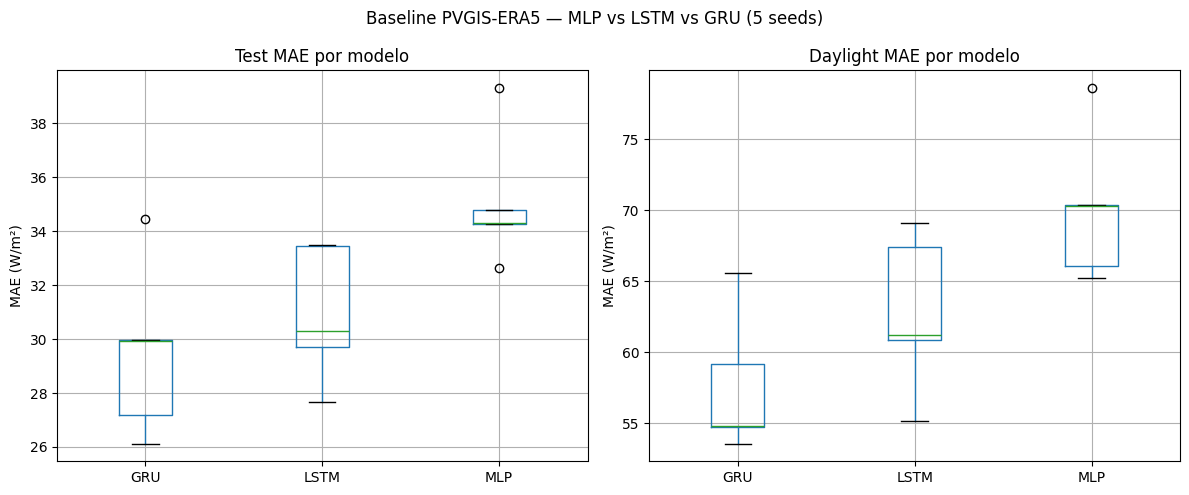

Guardado: /home/sergioperez/servidorjs/outputs/pvgis/figures/baseline_boxplot_mae.png


In [14]:
# Boxplot comparativo
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

results_df.boxplot(column="Test_MAE", by="Model", ax=axes[0])
axes[0].set_title("Test MAE por modelo")
axes[0].set_ylabel("MAE (W/m²)")
axes[0].set_xlabel("")

results_df.boxplot(column="Daylight_MAE", by="Model", ax=axes[1])
axes[1].set_title("Daylight MAE por modelo")
axes[1].set_ylabel("MAE (W/m²)")
axes[1].set_xlabel("")

plt.suptitle("Baseline PVGIS-ERA5 — MLP vs LSTM vs GRU (5 seeds)")
plt.tight_layout()

fig_path = os.path.join(FIGURES_DIR, "baseline_boxplot_mae.png")
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print("Guardado:", fig_path)

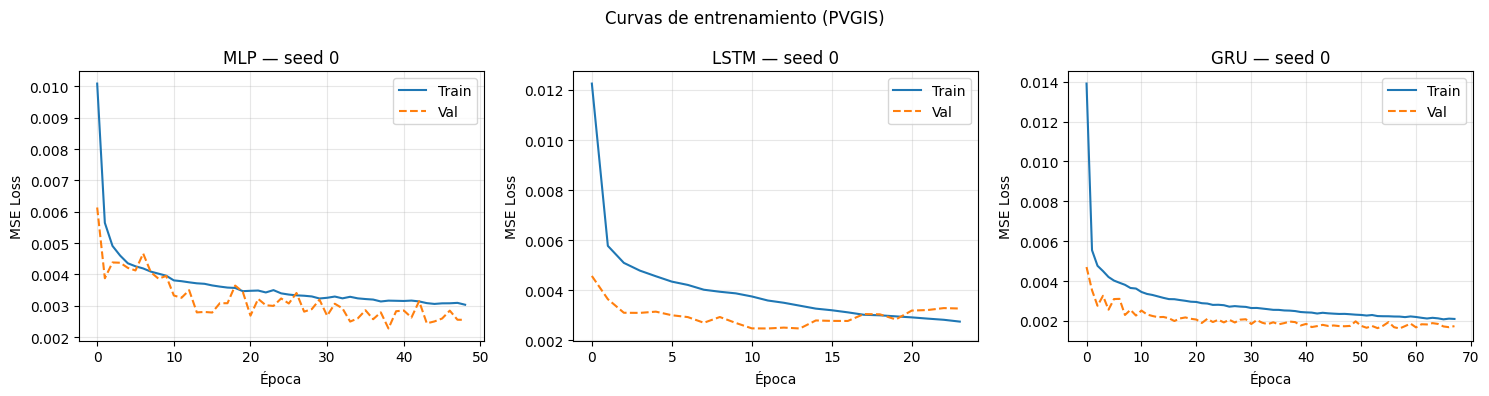

Guardado: /home/sergioperez/servidorjs/outputs/pvgis/figures/baseline_training_curves.png


In [15]:
# Curvas de entrenamiento del mejor modelo por tipo
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, model_name in zip(axes, ["MLP", "LSTM", "GRU"]):
    # Usar seed=0 como representativo
    h = histories[f"{model_name}_0"]
    ax.plot(h.history["loss"],     label="Train")
    ax.plot(h.history["val_loss"], label="Val", linestyle="--")
    ax.set_title(f"{model_name} — seed 0")
    ax.set_xlabel("Época")
    ax.set_ylabel("MSE Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Curvas de entrenamiento (PVGIS)")
plt.tight_layout()

fig_path = os.path.join(FIGURES_DIR, "baseline_training_curves.png")
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print("Guardado:", fig_path)

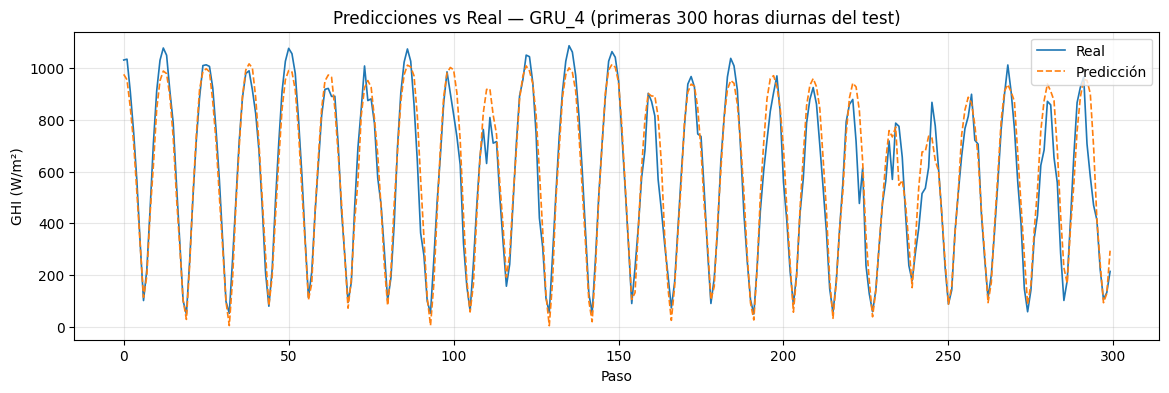

Guardado: /home/sergioperez/servidorjs/outputs/pvgis/figures/baseline_predictions_GRU_4.png


In [16]:
# Predicciones vs real — mejor modelo
best_key = f"{best['Model']}_{int(best['Seed'])}"
y_true_plot = predictions[best_key]["y_true"].flatten()
y_pred_plot = predictions[best_key]["y_pred"].flatten()

# Solo horas diurnas
mask = daylight_test
n = min(300, mask.sum())
idx = np.where(mask)[0][:n]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(y_true_plot[idx], label="Real",       linewidth=1.2)
ax.plot(y_pred_plot[idx], label="Predicción", linewidth=1.2, linestyle="--")
ax.set_title(f"Predicciones vs Real — {best_key} (primeras {n} horas diurnas del test)")
ax.set_ylabel("GHI (W/m²)")
ax.set_xlabel("Paso")
ax.legend()
ax.grid(True, alpha=0.3)

fig_path = os.path.join(FIGURES_DIR, f"baseline_predictions_{best_key}.png")
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print("Guardado:", fig_path)

## 9. Resumen final

In [17]:
print("=" * 60)
print("RESULTADOS BASELINE — PVGIS-ERA5 Querétaro")
print("=" * 60)
print(f"{'Modelo':<8} {'Test MAE':>10} {'±':>4} {'Daylight MAE':>14} {'±':>6} {'R² day':>8}")
print("-" * 60)
for _, row in summary_df.iterrows():
    print(f"{row.name:<8} "
          f"{row.Test_MAE_mean:>10.2f} "
          f"{row.Test_MAE_std:>4.2f} "
          f"{row.Daylight_MAE_mean:>14.2f} "
          f"{row.Daylight_MAE_std:>6.2f} "
          f"{row.Daylight_R2_mean:>8.4f}")
print("=" * 60)
print(f"Mejor baseline: {best['Model']} seed={int(best['Seed'])} "
      f"→ Daylight MAE={best['Daylight_MAE']:.2f} W/m²")
print("\n✓ Listo. Continuar con 03_benchmark.ipynb")

RESULTADOS BASELINE — PVGIS-ERA5 Querétaro
Modelo     Test MAE    ±   Daylight MAE      ±   R² day
------------------------------------------------------------
GRU           29.53 3.23          57.56   4.95   0.9220
LSTM          30.93 2.53          62.75   5.60   0.9106
MLP           35.07 2.51          70.09   5.31   0.8921
Mejor baseline: GRU seed=4 → Daylight MAE=53.56 W/m²

✓ Listo. Continuar con 03_benchmark.ipynb
